In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import os
import numpy as np

# --- 1. Dataset Klasse ---
class MotorMelDataset(Dataset):
    def __init__(self, directory, transform=None):
        self.directory = directory
        self.transform = transform
        self.images = [f for f in os.listdir(directory) if f.endswith('.png')]
        
        # Klassen-Logik: Alles mit 'CamChain' oder im Defekt-Ordner ist Klasse 1
        # Deine gesunden Files sind Klasse 0
        self.labels = []
        for img in self.images:
            if 'CamChain' in img or 'Defekt' in img or 'Rattle' in img:
                self.labels.append(1)
            else:
                self.labels.append(0)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.directory, self.images[idx])
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, self.labels[idx]

# --- 2. Architektur: EfficientNet-B0 mit Feature-Output ---
class EfficientDiagnoser(nn.Module):
    def __init__(self, num_classes=2):
        super(EfficientDiagnoser, self).__init__()
        # EfficientNet ist spezialisiert auf feine Texturen (wie deine Striche)
        self.base = models.efficientnet_b0(pretrained=True)
        
        # Classifier ersetzen
        in_features = self.base.classifier[1].in_features
        self.base.classifier = nn.Identity() # Wir nehmen die Features davor ab
        
        self.head = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        features = self.base(x)
        logits = self.head(features)
        return logits, features

# --- 3. Training Setup ---
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
model = EfficientDiagnoser(num_classes=2).to(device)

# Hartes Augmenting gegen den YouTube-Bias
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(), # Zeitlich spiegeln ist bei Idle ok
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.2), # Simuliert Datenverlust/Kompression
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Pfade anpassen (Kombiniere ggf. beide Ordner in eine Liste oder kopiere sie zusammen)
# Hier gehen wir davon aus, dass alle Bilder (Mel) in einem Ordner liegen
train_dir = '../data/processed/dataset_idle_mel' 
dataset = MotorMelDataset(train_dir, transform=data_transforms)
train_loader = DataLoader(dataset, batch_size=16, shuffle=True)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001) # Niedrige LR für Fine-Tuning

# --- 4. Trainings-Schleife ---
print(f"Starte Training auf {device}...")
model.train()

for epoch in range(15):
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        logits, _ = model(inputs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(logits.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    print(f"Epoch {epoch+1}/15 | Loss: {running_loss/len(train_loader):.4f} | Acc: {100*correct/total:.2f}%")

# Modell speichern
torch.save(model.state_dict(), "../models/s1000_efficient_diagnoser.pth")
print("Modell gespeichert.")

Starte Training auf mps...
Epoch 1/15 | Loss: 0.3798 | Acc: 93.99%
Epoch 2/15 | Loss: 0.0464 | Acc: 100.00%
Epoch 3/15 | Loss: 0.0075 | Acc: 100.00%
Epoch 4/15 | Loss: 0.0029 | Acc: 100.00%
Epoch 5/15 | Loss: 0.0019 | Acc: 100.00%
Epoch 6/15 | Loss: 0.0015 | Acc: 100.00%
Epoch 7/15 | Loss: 0.0011 | Acc: 100.00%
Epoch 8/15 | Loss: 0.0008 | Acc: 100.00%
Epoch 9/15 | Loss: 0.0008 | Acc: 100.00%
Epoch 10/15 | Loss: 0.0006 | Acc: 100.00%
Epoch 11/15 | Loss: 0.0005 | Acc: 100.00%
Epoch 12/15 | Loss: 0.0010 | Acc: 100.00%
Epoch 13/15 | Loss: 0.0004 | Acc: 100.00%
Epoch 14/15 | Loss: 0.0004 | Acc: 100.00%
Epoch 15/15 | Loss: 0.0003 | Acc: 100.00%
Modell gespeichert.


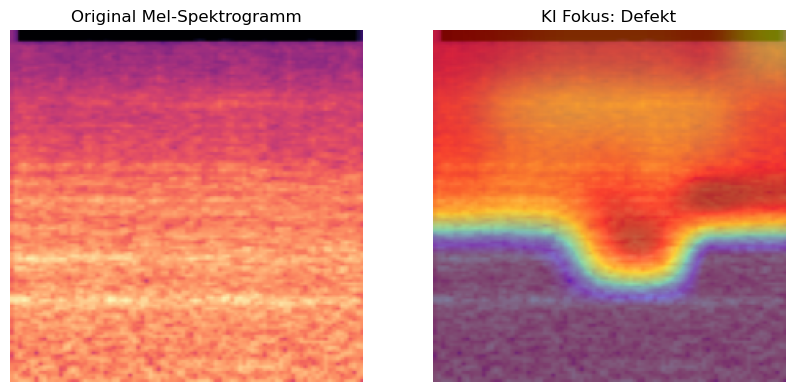

In [9]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

# --- 1. Modell laden ---
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = EfficientDiagnoser(num_classes=2).to(device)
model.load_state_dict(torch.load("../models/s1000_efficient_diagnoser.pth"))
model.eval()

def generate_gradcam(img_path, target_class=1):
    model.eval()
    
    # Bild laden und vorbereiten
    img_pil = Image.open(img_path).convert('RGB')
    input_tensor = data_transforms(img_pil).unsqueeze(0).to(device)
    
    # 1. Feature Maps und Gradienten speichern
    feature_maps = []
    gradients = []

    def save_feature_maps(module, input, output):
        feature_maps.append(output)

    def save_gradients(module, grad_input, grad_output):
        gradients.append(grad_output[0])

    # Der letzte Conv-Layer bei EfficientNet-B0 ist in features[8]
    target_layer = model.base.features[8]
    
    # Hooks registrieren
    handle_forward = target_layer.register_forward_hook(save_feature_maps)
    handle_backward = target_layer.register_full_backward_hook(save_gradients)

    # 2. Forward Pass
    logits, _ = model(input_tensor)
    
    # 3. Backward Pass für die Zielklasse
    model.zero_grad()
    loss = logits[0, target_class]
    loss.backward()

    # Hooks entfernen
    handle_forward.remove()
    handle_backward.remove()

    # 4. Heatmap berechnen
    # Global Average Pooling der Gradienten
    weights = torch.mean(gradients[0], dim=(2, 3), keepdim=True)
    
    # Gewichtete Kombination der Feature Maps
    heatmap = torch.sum(weights * feature_maps[0], dim=1).squeeze()
    
    # ReLU auf die Heatmap (nur positive Einflüsse zählen)
    heatmap = F.relu(heatmap)
    
    # Normalisierung auf [0, 1]
    heatmap /= (torch.max(heatmap) + 1e-8)
    heatmap = heatmap.cpu().detach().numpy()

    # 5. Visualisierung
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img_pil)
    plt.title("Original Mel-Spektrogramm")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(img_pil)
    # Heatmap skalieren und drüberlegen
    heatmap_resized = np.array(Image.fromarray(np.uint8(255 * heatmap)).resize(img_pil.size, resample=Image.BICUBIC))
    plt.imshow(heatmap_resized, cmap='jet', alpha=0.5)
    plt.title(f"KI Fokus: {'Defekt' if target_class == 1 else 'Gesund'}")
    plt.axis('off')
    
    plt.show()


# --- Teste es an einem kritischen Bild ---
test_img = '../data/processed/dataset_idle_mel/S1000R_2014_YoutubeVToldsMotoShow_idle_3.50s.png'
#test_img = '../data/processed/dataset_idle_mel_defective/S1000RR_2014_YoutubeVasylSuprovych_CamChainRattle_idle_1.50s.png'
generate_gradcam(test_img, target_class=1)